# Ödev 1 – Makine Algılaması ve Veri Temsili

**Ad Soyad:** Shohrat Merdanov
**Öğrenci No:** _[250121049]_
**Ders:** Makine Öğrenmesi – Hafta 2

---

**Amaç:** Bir yapay zeka sisteminin çevreden aldığı görüntü verisinin bilgisayarda nasıl temsil edildiğini görmek; görüntünün boyutunu, kanal bilgisini ve temel piksel istatistiklerini incelemek.

**Seçilen görüntü:** `kedi.png` – scikit-image kütüphanesiyle birlikte gelen, serbestçe kullanılabilen "Chelsea" adlı kedi fotoğrafı.
**Neden bu görüntü?** Tek ve belirgin bir nesne (kedi) içeriyor, renkli (RGB) ve boyutu küçük. Bu yüzden hem kanal yapısını hem de "bir sınıflandırma modeli bu görüntüden ne öğrenir?" sorusunu açıklamak için çok uygun. Ayrıca kütüphaneden geldiği için notebook her bilgisayarda aynı sonucu verir.

## 1. Kütüphanelerin Yüklenmesi

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data  # örnek görüntü için (Colab'da hazır yüklü gelir)

print("NumPy sürümü :", np.__version__)
print("Pillow sürümü:", Image.__version__)

NumPy sürümü : 2.4.4
Pillow sürümü: 12.2.0


## 2. Görüntü Dosyasının Yüklenmesi ve Açılması

Aşağıdaki hücre çalışma klasöründe `kedi.png` dosyasını arar:
- Dosyayı Colab'a sol menüdeki **Dosyalar** bölümünden yüklediyseniz o dosya açılır.
- Dosya yoksa aynı fotoğraf scikit-image kütüphanesinden alınıp `kedi.png` olarak kaydedilir; böylece notebook her durumda **hatasız** çalışır.

Görüntü daha sonra Pillow (`Image.open`) ile bir dosya olarak açılır.

'kedi.png' bulunamadı, örnek görüntü kaydedildi.
Dosya         : kedi.png
Dosya boyutu  : 215.6 KB
Pillow modu   : RGB


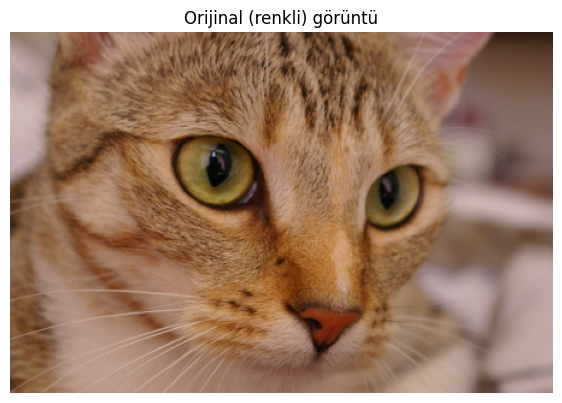

In [2]:
DOSYA_ADI = "kedi.png"

# Kendi bilgisayarınızdan dosya seçmek isterseniz aşağıdaki iki satırın başındaki # işaretini kaldırın:
# from google.colab import files
# yuklenen = files.upload(); DOSYA_ADI = list(yuklenen.keys())[0]

if not os.path.exists(DOSYA_ADI):
    Image.fromarray(data.chelsea()).save(DOSYA_ADI)
    print(f"'{DOSYA_ADI}' bulunamadı, örnek görüntü kaydedildi.")

img = Image.open(DOSYA_ADI).convert("RGB")
print("Dosya         :", DOSYA_ADI)
print("Dosya boyutu  :", round(os.path.getsize(DOSYA_ADI) / 1024, 1), "KB")
print("Pillow modu   :", img.mode)

plt.figure(figsize=(7, 5))
plt.imshow(img)
plt.title("Orijinal (renkli) görüntü")
plt.axis("off")
plt.show()

## 3. Genişlik, Yükseklik ve Kanal Sayısı

Görüntüyü NumPy dizisine çevirdiğimizde bilgisayarın onu aslında **sayılardan oluşan bir tablo** olarak gördüğünü fark ederiz. Dizinin şekli `(yükseklik, genişlik, kanal)` biçimindedir.

In [3]:
arr = np.array(img)

yukseklik, genislik, kanal = arr.shape
print("Dizi şekli (shape) :", arr.shape)
print("Genişlik           :", genislik, "piksel")
print("Yükseklik          :", yukseklik, "piksel")
print("Kanal sayısı       :", kanal, "(R, G, B)")
print("Veri tipi (dtype)  :", arr.dtype, "-> her değer 0-255 arasında bir tam sayı")
print("Toplam piksel      :", genislik * yukseklik)
print("Toplam sayı (girdi):", arr.size, "= genişlik x yükseklik x kanal")

Dizi şekli (shape) : (300, 451, 3)
Genişlik           : 451 piksel
Yükseklik          : 300 piksel
Kanal sayısı       : 3 (R, G, B)
Veri tipi (dtype)  : uint8 -> her değer 0-255 arasında bir tam sayı
Toplam piksel      : 135300
Toplam sayı (girdi): 405900 = genişlik x yükseklik x kanal


### Ek: Bir pikselin ve küçük bir bölgenin sayısal karşılığı
Tek bir piksel 3 sayıdan (kırmızı, yeşil, mavi) oluşur. Aşağıda görüntünün ortasındaki pikselin değerleri ve 5x5'lik küçük bir bölgenin kırmızı kanalı gösterilmiştir.

In [4]:
orta_y, orta_x = yukseklik // 2, genislik // 2
print(f"({orta_y}, {orta_x}) konumundaki pikselin [R, G, B] değeri:", arr[orta_y, orta_x])
print("\nAynı bölgedeki 5x5 piksellik alanın kırmızı (R) kanalı:")
print(arr[orta_y:orta_y + 5, orta_x:orta_x + 5, 0])

(150, 225) konumundaki pikselin [R, G, B] değeri: [190 150 124]

Aynı bölgedeki 5x5 piksellik alanın kırmızı (R) kanalı:
[[190 190 189 188 193]
 [192 186 174 192 201]
 [163 174 197 194 196]
 [180 194 189 192 194]
 [183 192 196 188 187]]


### Ek: Kanalların ayrı ayrı gösterimi
Renkli görüntü aslında üst üste konmuş üç ayrı gri tablodan oluşur.

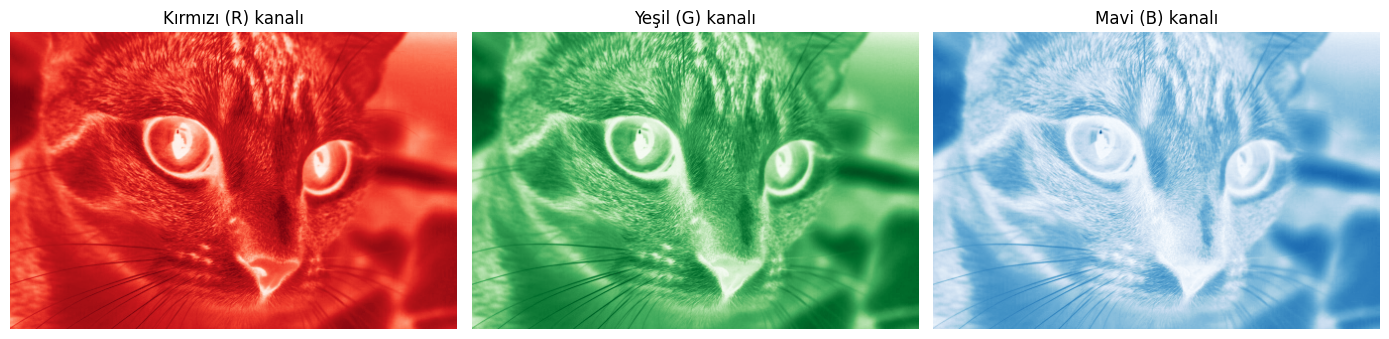

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (ad, cmap) in enumerate([("Kırmızı (R)", "Reds"), ("Yeşil (G)", "Greens"), ("Mavi (B)", "Blues")]):
    axes[i].imshow(arr[:, :, i], cmap=cmap)
    axes[i].set_title(f"{ad} kanalı")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 4. Gri Tona Dönüştürme

Pillow'un `convert("L")` fonksiyonu her pikseli şu formülle tek bir parlaklık değerine indirger (ITU-R 601-2):

$$L = 0.299\,R + 0.587\,G + 0.114\,B$$

Böylece 3 kanal 1 kanala düşer ve modele verilecek sayı miktarı üçte birine iner.

Gri ton dizi şekli: (300, 451) -> artık tek kanal
Renkli girdi sayısı: 405900 | Gri girdi sayısı: 135300


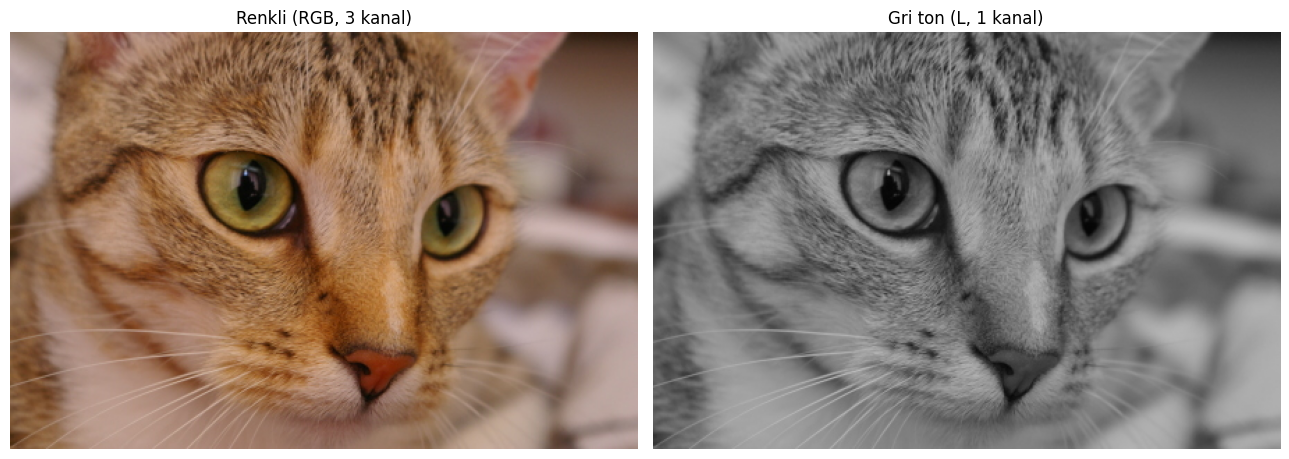

In [6]:
gri = img.convert("L")
gri_arr = np.array(gri)
print("Gri ton dizi şekli:", gri_arr.shape, "-> artık tek kanal")
print("Renkli girdi sayısı:", arr.size, "| Gri girdi sayısı:", gri_arr.size)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(img);                       axes[0].set_title("Renkli (RGB, 3 kanal)"); axes[0].axis("off")
axes[1].imshow(gri_arr, cmap="gray", vmin=0, vmax=255); axes[1].set_title("Gri ton (L, 1 kanal)");  axes[1].axis("off")
plt.tight_layout()
plt.show()

## 5. Temel Piksel İstatistikleri

Ortalama, minimum ve maksimum değerler hem gri ton görüntü hem de her renk kanalı için hesaplanmıştır.

In [7]:
print("=== Gri ton görüntü ===")
print(f"Ortalama : {gri_arr.mean():.2f}")
print(f"Minimum  : {gri_arr.min()}")
print(f"Maksimum : {gri_arr.max()}")
print(f"Std. sapma: {gri_arr.std():.2f}")

print("\n=== Renk kanalları ===")
print(f"{'Kanal':<6}{'Ortalama':>10}{'Min':>6}{'Maks':>6}")
for i, ad in enumerate(["R", "G", "B"]):
    k = arr[:, :, i]
    print(f"{ad:<6}{k.mean():>10.2f}{k.min():>6}{k.max():>6}")

=== Gri ton görüntü ===
Ortalama : 119.48
Minimum  : 4
Maksimum : 194
Std. sapma: 32.12

=== Renk kanalları ===
Kanal   Ortalama   Min  Maks
R         147.67     2   215
G         111.44     4   189
B          86.80     0   231


### Ek: Gri ton histogramı
Histogram, hangi parlaklık değerlerinin görüntüde ne kadar sık geçtiğini gösterir. Kırmızı çizgi ortalamayı işaret eder.

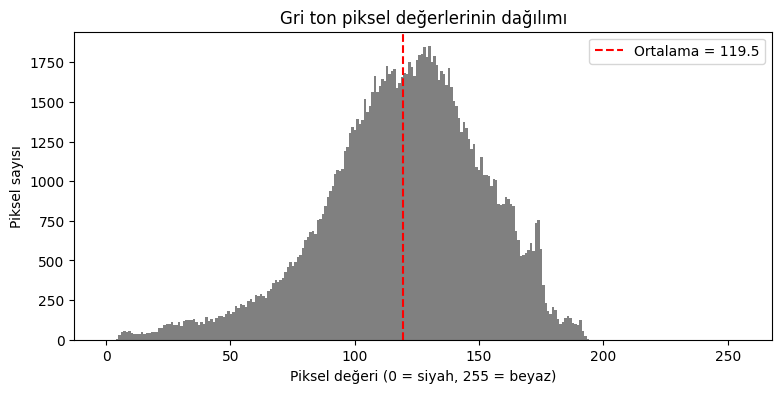

In [8]:
plt.figure(figsize=(9, 4))
plt.hist(gri_arr.ravel(), bins=256, range=(0, 255), color="gray")
plt.axvline(gri_arr.mean(), color="red", linestyle="--", label=f"Ortalama = {gri_arr.mean():.1f}")
plt.title("Gri ton piksel değerlerinin dağılımı")
plt.xlabel("Piksel değeri (0 = siyah, 255 = beyaz)")
plt.ylabel("Piksel sayısı")
plt.legend()
plt.show()

### Ek: Modele girmeden önceki hazırlık (normalizasyon)
Modeller genellikle 0-255 yerine 0-1 aralığındaki sayılarla daha kararlı öğrenir. Aşağıda görüntü hem ölçeklendirilmiş hem de tek satırlık bir girdi vektörüne dönüştürülmüştür.

In [9]:
girdi = gri_arr.astype(np.float32) / 255.0
vektor = girdi.flatten()
print("Normalize edilmiş aralık :", vektor.min(), "-", vektor.max())
print("Düzleştirilmiş vektör boyu:", vektor.shape[0], "sayı")
print("İlk 10 değer             :", np.round(vektor[:10], 3))

Normalize edilmiş aralık : 0.015686275 - 0.7607843
Düzleştirilmiş vektör boyu: 135300 sayı
İlk 10 değer             : [0.49  0.49  0.482 0.482 0.482 0.482 0.482 0.49  0.494 0.498]


## 6. Yorum: Bu görüntü bir sınıflandırma sistemine girdi olduğunda model neyi öğrenmeye çalışabilir?

Bilgisayar bu fotoğrafı bir kedi olarak değil, 300 satır ve 451 sütundan oluşan, her hücresinde 3 sayı bulunan bir tablo olarak görür; yani model için girdi toplam 405.900 sayıdan ibarettir. Bir sınıflandırma modeli bu sayılarla, örneğin "kedi" ya da "köpek" gibi bir etiket arasındaki bağlantıyı bulmaya çalışır. İlk aşamada model, komşu pikseller arasındaki ani parlaklık değişimlerinden kenarları ve çizgileri yakalamayı öğrenebilir. Daha sonra bu kenarları birleştirerek kulak, göz, burun ve bıyık gibi parçaların şekillerini, kürkün çizgili dokusunu ve renk tonlarını ayırt edici özellik olarak kullanabilir. Bu görüntüde gri ton ortalamasının yaklaşık 119 olması ve değerlerin 4 ile 194 arasına yayılması, fotoğrafta hem karanlık hem de aydınlık bölgeler, yani modelin kullanabileceği belirgin kontrastlar olduğunu gösterir; kırmızı kanal ortalamasının maviden belirgin şekilde yüksek olması da kürkün sıcak, kahverengi tonlarını yansıtır. Gri tona çevirdiğimizde renk bilgisi kaybolur ama şekil ve doku bilgisi büyük ölçüde korunur; bu da kedinin rengi değil biçimi önemliyse modelin daha az veriyle çalışmasını sağlar. Ancak model tek bir fotoğraftan genel bir kural çıkaramaz; farklı ışık, açı, arka plan ve ırklardan çok sayıda etiketli örnek görmesi gerekir. Aksi hâlde model kediyi değil, örneğin arka plandaki renkleri veya ışık koşulunu ezberleyebilir. Sonuç olarak model, ham piksel değerlerinden başlayıp adım adım daha anlamlı özelliklere ulaşarak "bu sayılar hangi sınıfa ait?" sorusunu cevaplamayı öğrenmeye çalışır.

## Kaynaklar

- Google Colab – https://colab.research.google.com
- Pillow dokümantasyonu, `Image.open` ve `Image.convert` – https://pillow.readthedocs.io/en/stable/reference/Image.html
- NumPy resmi dokümantasyonu, `ndarray`, `mean`, `min`, `max` – https://numpy.org/doc/stable/
- Matplotlib dokümantasyonu, `imshow` ve `hist` – https://matplotlib.org/stable/
- scikit-image örnek veri seti, `skimage.data.chelsea` (görüntünün kaynağı) – https://scikit-image.org/docs/stable/api/skimage.data.html

## Yapay Zeka Aracı Kullanım Beyanı

Bu ödevde Anthropic'in Claude adlı yapay zeka asistanından yardım aldım. Claude'u notebook'un kod yapısını oluşturmak, uygun örnek görüntüyü seçmek ve yorum bölümü için taslak hazırlamak amacıyla kullandım. Kodu kendim çalıştırıp çıktıları kontrol ettim ve yorum bölümünü kendi anladığım şekilde düzenledim.